<a href="https://colab.research.google.com/github/Hernandez484/01.01-PROYECTO-KAGGLE/blob/main/05%20-%20preprocesado%20agrupando%20las%20carreras%20y%20tratamiento%20datos%20NaN%20sin%20eliminar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

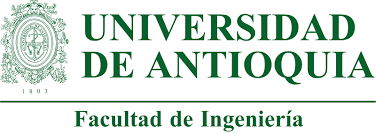

# <font color='056938'> **01.01 - PROYECTO KAGGLE - </font> <font color='8EC044'> Entrega Final "Preprocesado Agrupando las Carreras y Tratamiento de Datos `NAN` Sin Eliminar"** </font>

## <font color='157699'> **Paso 1:** </font>

In [1]:
!wget --no-cache -O init.py -q https://raw.githubusercontent.com/rramosp/ai4eng.v1/main/content/init.py
import init; init.init(force_download=False); init.get_weblink()

replicating local resources


## <font color='157699'> **Paso 2: Descargar datos directamente desde Kaggle** </font>

- Se creo un archivo kaggle.jsoncon con mi token de autenticación (en kaggle $\to$ Hago clic en el icono de usuario en la parte superior derecha $\to$
ajustes $\to$ API crea un nuevo token);

- Subirlo a este espacio de trabajo del cuaderno;

- Y ejecutar la siguiente celda.

In [3]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '.'
!chmod 600 ./kaggle.json
!kaggle competitions download --force udea-ai-4-eng-20252-pruebas-saber-pro-colombia

  0% 0.00/29.9M [00:00<?, ?B/s]
100% 29.9M/29.9M [00:00<00:00, 979MB/s]


## <font color='157699'> **Paso 3: Descomprimir e inspeccionar datos** </font>

Se descomprime el fichero.

In [4]:
!unzip udea*.zip > /dev/null

In [5]:
!wc *.csv

   296787    296787   4716673 submission_example.csv
   296787   4565553  59185238 test.csv
   692501  10666231 143732437 train.csv
  1286075  15528571 207634348 total


## <font color='157699'> **Paso 4: Se carga `train.csv` con la librería `Pandas`** </font>

In [6]:
import pandas as pd
import numpy as np

#z = pd.read_csv("train.csv")
#print ("shape of loaded dataframe", z.shape)
z = pd.read_csv("test.csv")
print ("shape of loaded dataframe", z.shape)

shape of loaded dataframe (296786, 20)


In [7]:
z.head()

,ID,PERIODO_ACADEMICO,E_PRGM_ACADEMICO,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_TIENEINTERNET.1,F_EDUCACIONMADRE,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4
0,550236,20183,TRABAJO SOCIAL,BOLIVAR,Menos de 500 mil,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Si,No,N,Si,Si,Si,Primaria completa,0.328,0.219,0.317,0.247
1,98545,20203,ADMINISTRACION COMERCIAL Y DE MERCADEO,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,Si,Si,Técnica o tecnológica completa,0.227,0.283,0.296,0.324
2,499179,20212,INGENIERIA MECATRONICA,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Si,No,N,No,Si,Si,Secundaria (Bachillerato) completa,0.285,0.228,0.294,0.247
3,782980,20195,CONTADURIA PUBLICA,SUCRE,Entre 1 millón y menos de 2.5 millones,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Si,No,N,No,No,No,Primaria incompleta,0.160,0.408,0.217,0.294
4,785185,20212,ADMINISTRACION DE EMPRESAS,ATLANTICO,Entre 2.5 millones y menos de 4 millones,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,Si,Si,Secundaria (Bachillerato) completa,0.209,0.283,0.306,0.286


**Información general**

Considerando que se tiene en total 692K elementos de datos, se tiene relativamente pocos valores faltantes en cada columna.

In [8]:
z.isna().sum()

,0
ID,0
PERIODO_ACADEMICO,0
E_PRGM_ACADEMICO,0
E_PRGM_DEPARTAMENTO,0
E_VALORMATRICULAUNIVERSIDAD,2723
E_HORASSEMANATRABAJA,13379
F_ESTRATOVIVIENDA,13795
F_TIENEINTERNET,11539
F_EDUCACIONPADRE,9993
F_TIENELAVADORA,17259


In [9]:
z.dtypes

,0
ID,int64
PERIODO_ACADEMICO,int64
E_PRGM_ACADEMICO,object
E_PRGM_DEPARTAMENTO,object
E_VALORMATRICULAUNIVERSIDAD,object
E_HORASSEMANATRABAJA,object
F_ESTRATOVIVIENDA,object
F_TIENEINTERNET,object
F_EDUCACIONPADRE,object
F_TIENELAVADORA,object


**Revisión de columnas**

**Periodo**

Posibilidades:
* Se puede separar el año del periodo en dos columnas y trabajarlo en numeros(Recomendado por el Profe) o como etiquetas.
* Trabajar los periodos como etiquetas o numeros.

**Nota:** Trabarla como etiquetas no nos permitiria predecir cosas que esten por fuera de esos periodos. Puede ser util para que el modelo tenga más capacidad de predecir los valores del test(Y sacar un mejor Acurracy), pero podria generar un sobre ajuste.

In [10]:
sorted(z.PERIODO_ACADEMICO.unique())

[np.int64(20183),
 np.int64(20184),
 np.int64(20194),
 np.int64(20195),
 np.int64(20196),
 np.int64(20202),
 np.int64(20203),
 np.int64(20212),
 np.int64(20213)]

In [ ]:
#sorted(test.PERIODO_ACADEMICO.unique())

**Tratamiendo de columna: OneHot**

In [11]:
df_onehot = pd.get_dummies(z['PERIODO_ACADEMICO'], prefix='PER')
z = pd.concat([z, df_onehot], axis=1)

In [12]:
z = z.drop(columns=['PERIODO_ACADEMICO'])

In [13]:
z.head()

,ID,E_PRGM_ACADEMICO,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,...,INDICADOR_4,PER_20183,PER_20184,PER_20194,PER_20195,PER_20196,PER_20202,PER_20203,PER_20212,PER_20213
0,550236,TRABAJO SOCIAL,BOLIVAR,Menos de 500 mil,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Si,No,...,0.247,True,False,False,False,False,False,False,False,False
1,98545,ADMINISTRACION COMERCIAL Y DE MERCADEO,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,...,0.324,False,False,False,False,False,False,True,False,False
2,499179,INGENIERIA MECATRONICA,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Si,No,...,0.247,False,False,False,False,False,False,False,True,False
3,782980,CONTADURIA PUBLICA,SUCRE,Entre 1 millón y menos de 2.5 millones,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Si,No,...,0.294,False,False,False,True,False,False,False,False,False
4,785185,ADMINISTRACION DE EMPRESAS,ATLANTICO,Entre 2.5 millones y menos de 4 millones,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,...,0.286,False,False,False,False,False,False,False,True,False


**Programa Academico**

**Importante:** Una posible opción es clasificar las carreras como Ingenieria, Licenciatura, Ciencias Exactas, etc. Son muchas carreras para hacer onehot.

* El examen tiene areas como matematicas, Lectura Crítica, Sociales y Ciudadanas, ciencias naturales e ingles tal vez eso ayude a predecir.
* Buscar carreras con una distancia de edicion cortas como posibles carreras duplicadas.
* (¿Otras ideas?)

In [14]:
len(sorted(z.E_PRGM_ACADEMICO.unique()))

919

**Nota:** En este caso decidimos por organizar por tematica principal

**Tratamiento de columna: Reducción de etiqueta, mapeo y variable nominal**

In [15]:
len(z.E_PRGM_ACADEMICO.unique())

919

In [16]:
import pandas as pd
import numpy as np
import re

# Function to categorize academic programs based on keywords
def categorize_program(program):
    program = program.lower()  # Convert to lowercase for easier matching

    # Define mappings based on common keywords
    if re.search(r'admin|ges|neg|fin|conta', program):
        return 'Administracion_y_Negocios'

    elif re.search(r'(inge(nier.a)?)', program):
        return 'Ingenieria'

    elif re.search(r'lice|edu|pedago', program):
        return 'Licenciatura'

    elif re.search(r'(med.+?c(.+?)?[ao](\b|^))|(salud)|(farma)|(psic)|(terapia)|(veteri)|(enfer)', program):
        return 'Medicina'

    elif re.search(r'\bderecho|juridic', program):
        return 'Derecho'

    elif re.search(r'merc|publici|tecnia', program):
        return 'Mercadeo_y_Publicidad'

    elif re.search(r'comput', program):
        return 'Computacion'

    elif re.search(r'dise|art(e|.sti)|m[uú]s|cine|telev|audiovis|fotog|danz|tea|core', program):
        return 'Artes'

    elif re.search(r'cienc((.+?\bnat)|.+?^)|geo|bio|qu.m|f.sic|amb', program) and not re.search(r'edu|deporte|recre', program):
        return 'Ciencias'

    elif re.search(r'cienc.+?soci|sociolo|human|antropolog|histor|filos|', program):
        return 'Ciencias_Sociales_y_Humanidades'

    elif re.search(r'filol|letr', program):
        return 'Letras'

    elif re.search(r'idio|leng|extr|espa..?ol|ingl|fran', program):
        return 'Lenguas'

    else:
        return 'Otros'

In [17]:
len(z.E_PRGM_ACADEMICO.unique())

919

In [18]:
sorted(z.E_PRGM_ACADEMICO.unique())

['3°  CICLO PROFESIONAL NEGOCIOS INTERNACIONALES',
 'ACTIVIDAD FISICA Y DEPORTE',
 'ACUICULTURA',
 'ADMINISTRACION',
 'ADMINISTRACION  DE EMPRESAS.',
 'ADMINISTRACION  FINANCIERA',
 'ADMINISTRACION & SERVICIO',
 'ADMINISTRACION AERONAUTICA',
 'ADMINISTRACION AGROPECUARIA',
 'ADMINISTRACION AMBIENTAL',
 'ADMINISTRACION AMBIENTAL Y DE LOS RECURSOS NATURALES',
 'ADMINISTRACION BANCARIA Y FINANCIERA',
 'ADMINISTRACION COMERCIAL',
 'ADMINISTRACION COMERCIAL Y DE MERCADEO',
 'ADMINISTRACION DE EMPRESAS',
 'ADMINISTRACION DE EMPRESAS  Y  GESTION AMBIENTAL',
 'ADMINISTRACION DE EMPRESAS AGROINDUSTRIALES',
 'ADMINISTRACION DE EMPRESAS AGROPECUARIAS',
 'ADMINISTRACION DE EMPRESAS COMERCIALES',
 'ADMINISTRACION DE EMPRESAS EN TELECOMUNICACIONES',
 'ADMINISTRACION DE EMPRESAS TURISTICA',
 'ADMINISTRACION DE EMPRESAS TURISTICAS',
 'ADMINISTRACION DE EMPRESAS TURISTICAS Y HOTELERAS',
 'ADMINISTRACION DE EMPRESAS TURÍSTICAS Y HOTELERAS',
 'ADMINISTRACION DE EMPRESAS Y FINANZAS',
 'ADMINISTRACION DE E

In [19]:
z.E_PRGM_ACADEMICO

,E_PRGM_ACADEMICO
0,TRABAJO SOCIAL
1,ADMINISTRACION COMERCIAL Y DE MERCADEO
2,INGENIERIA MECATRONICA
3,CONTADURIA PUBLICA
4,ADMINISTRACION DE EMPRESAS
...,...
296781,ADMINISTRACION DE EMPRESAS
296782,DERECHO
296783,DERECHO
296784,INGENIERIA AERONAUTICA


In [21]:
z['Categoria'] = z['E_PRGM_ACADEMICO'].apply(categorize_program)
z['Categoria'].value_counts()

,count
Categoria,
Administracion_y_Negocios,86462
Ingenieria,63195
Medicina,42467
Ciencias_Sociales_y_Humanidades,36844
Licenciatura,28156
Derecho,23170
Artes,7725
Mercadeo_y_Publicidad,5229
Ciencias,3477


In [22]:
del z["E_PRGM_ACADEMICO"]
z.head()

,ID,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,...,PER_20183,PER_20184,PER_20194,PER_20195,PER_20196,PER_20202,PER_20203,PER_20212,PER_20213,Categoria
0,550236,BOLIVAR,Menos de 500 mil,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Si,No,N,...,True,False,False,False,False,False,False,False,False,Ciencias_Sociales_y_Humanidades
1,98545,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,...,False,False,False,False,False,False,True,False,False,Administracion_y_Negocios
2,499179,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Si,No,N,...,False,False,False,False,False,False,False,True,False,Ingenieria
3,782980,SUCRE,Entre 1 millón y menos de 2.5 millones,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Si,No,N,...,False,False,False,True,False,False,False,False,False,Administracion_y_Negocios
4,785185,ATLANTICO,Entre 2.5 millones y menos de 4 millones,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,...,False,False,False,False,False,False,False,True,False,Administracion_y_Negocios


**OneHot**

In [23]:
df_onehot = pd.get_dummies(z['Categoria'])
z = pd.concat([z, df_onehot], axis=1)
del z["Categoria"]
z.head()

,ID,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,...,Administracion_y_Negocios,Artes,Ciencias,Ciencias_Sociales_y_Humanidades,Computacion,Derecho,Ingenieria,Licenciatura,Medicina,Mercadeo_y_Publicidad
0,550236,BOLIVAR,Menos de 500 mil,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Si,No,N,...,False,False,False,True,False,False,False,False,False,False
1,98545,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,...,True,False,False,False,False,False,False,False,False,False
2,499179,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Si,No,N,...,False,False,False,False,False,False,True,False,False,False
3,782980,SUCRE,Entre 1 millón y menos de 2.5 millones,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Si,No,N,...,True,False,False,False,False,False,False,False,False,False
4,785185,ATLANTICO,Entre 2.5 millones y menos de 4 millones,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,...,True,False,False,False,False,False,False,False,False,False


In [24]:
z.head()

,ID,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,...,Administracion_y_Negocios,Artes,Ciencias,Ciencias_Sociales_y_Humanidades,Computacion,Derecho,Ingenieria,Licenciatura,Medicina,Mercadeo_y_Publicidad
0,550236,BOLIVAR,Menos de 500 mil,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Si,No,N,...,False,False,False,True,False,False,False,False,False,False
1,98545,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,...,True,False,False,False,False,False,False,False,False,False
2,499179,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Si,No,N,...,False,False,False,False,False,False,True,False,False,False
3,782980,SUCRE,Entre 1 millón y menos de 2.5 millones,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Si,No,N,...,True,False,False,False,False,False,False,False,False,False
4,785185,ATLANTICO,Entre 2.5 millones y menos de 4 millones,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,...,True,False,False,False,False,False,False,False,False,False


**Departamento**

In [25]:
len(z.E_PRGM_DEPARTAMENTO.unique())

31

In [26]:
len(sorted(z.E_PRGM_DEPARTAMENTO.unique()))

31

**Tratamiendo de columna: Variable nominal**

In [27]:
#Se eliminan los espacios para poder acceder a la variables asi: z.EL_DEPARTAMENTO
z['E_PRGM_DEPARTAMENTO'] = z['E_PRGM_DEPARTAMENTO'].str.replace(' ', '_')
sorted(z.E_PRGM_DEPARTAMENTO.unique())

['AMAZONAS',
 'ANTIOQUIA',
 'ARAUCA',
 'ATLANTICO',
 'BOGOTÁ',
 'BOLIVAR',
 'BOYACA',
 'CALDAS',
 'CAQUETA',
 'CASANARE',
 'CAUCA',
 'CESAR',
 'CHOCO',
 'CORDOBA',
 'CUNDINAMARCA',
 'GUAVIARE',
 'HUILA',
 'LA_GUAJIRA',
 'MAGDALENA',
 'META',
 'NARIÑO',
 'NORTE_SANTANDER',
 'PUTUMAYO',
 'QUINDIO',
 'RISARALDA',
 'SANTANDER',
 'SAN_ANDRES',
 'SUCRE',
 'TOLIMA',
 'VALLE',
 'VAUPES']

**OneHot**

In [29]:
df_onehot = pd.get_dummies(z['E_PRGM_DEPARTAMENTO'], prefix='DEP')
z = pd.concat([z, df_onehot], axis=1)

In [30]:
z.head()

,ID,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,550236,BOLIVAR,Menos de 500 mil,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Si,No,N,...,False,False,False,False,False,False,False,False,False,False
1,98545,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,...,False,False,False,False,False,False,False,False,False,False
2,499179,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Si,No,N,...,False,False,False,False,False,False,False,False,False,False
3,782980,SUCRE,Entre 1 millón y menos de 2.5 millones,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Si,No,N,...,False,False,False,False,False,False,True,False,False,False
4,785185,ATLANTICO,Entre 2.5 millones y menos de 4 millones,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,...,False,False,False,False,False,False,False,False,False,False


In [31]:
z.drop(columns=['E_PRGM_DEPARTAMENTO'], inplace=True)

In [32]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,550236,Menos de 500 mil,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Si,No,N,Si,...,False,False,False,False,False,False,False,False,False,False
1,98545,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
2,499179,Entre 1 millón y menos de 2.5 millones,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
3,782980,Entre 1 millón y menos de 2.5 millones,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Si,No,N,No,...,False,False,False,False,False,False,True,False,False,False
4,785185,Entre 2.5 millones y menos de 4 millones,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False


**Decisiones de las columnas con NAN**

**Con el precio de la matricula**

Posibildades de preprocesamiento:
* Agrupar en clases y trabajarlo como variables ordinales. Ejemplo : * No pago matricula: 0, Menos de 500 mil: 1, ...
* Promedio de los valores.
* Agarrar el inferior o el superior.
* Trabajarlo como etiquetas (OneHot)

Posibiliades para la valores nulos:
* Media
* Moda
* Mediana
* Descartarlos
* Por un valor particular
* Cosiderar que no pagaron nada

In [33]:
z.E_VALORMATRICULAUNIVERSIDAD.unique()

array(['Menos de 500 mil', 'Entre 2.5 millones y menos de 4 millones',
       'Entre 1 millón y menos de 2.5 millones',
       'Entre 500 mil y menos de 1 millón', 'Más de 7 millones',
       'Entre 4 millones y menos de 5.5 millones',
       'Entre 5.5 millones y menos de 7 millones', 'No pagó matrícula',
       nan], dtype=object)

In [34]:
(z.shape[0], z.E_VALORMATRICULAUNIVERSIDAD.isna().sum(), z.E_VALORMATRICULAUNIVERSIDAD.isna().sum()/z.shape[0])

(296786, np.int64(2723), np.float64(0.009174961083069956))

**Tratamiento de la columna: Variable ordinal**

In [35]:
z.E_VALORMATRICULAUNIVERSIDAD

,E_VALORMATRICULAUNIVERSIDAD
0,Menos de 500 mil
1,Entre 2.5 millones y menos de 4 millones
2,Entre 1 millón y menos de 2.5 millones
3,Entre 1 millón y menos de 2.5 millones
4,Entre 2.5 millones y menos de 4 millones
...,...
296781,Entre 2.5 millones y menos de 4 millones
296782,Entre 1 millón y menos de 2.5 millones
296783,Entre 2.5 millones y menos de 4 millones
296784,Entre 5.5 millones y menos de 7 millones


In [36]:
cmap = {'No pagó matrícula': 0,
        'Menos de 500 mil': 1,
        'Entre 500 mil y menos de 1 millón': 2,
        'Entre 1 millón y menos de 2.5 millones': 3,
        'Entre 2.5 millones y menos de 4 millones': 4,
        'Entre 4 millones y menos de 5.5 millones': 5,
        'Entre 5.5 millones y menos de 7 millones': 6,
        'Más de 7 millones': 7}

z['E_VALORMATRICULAUNIVERSIDAD'] = z['E_VALORMATRICULAUNIVERSIDAD'].replace(cmap)

z.E_VALORMATRICULAUNIVERSIDAD.value_counts()
z.head()

/tmp/ipython-input-1439519292.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z['E_VALORMATRICULAUNIVERSIDAD'] = z['E_VALORMATRICULAUNIVERSIDAD'].replace(cmap)


,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,550236,1.0,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Si,No,N,Si,...,False,False,False,False,False,False,False,False,False,False
1,98545,4.0,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
2,499179,3.0,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
3,782980,3.0,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Si,No,N,No,...,False,False,False,False,False,False,True,False,False,False
4,785185,4.0,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False


**Tratamiento de los NaN: Mediana**

In [37]:
# Calcular la mediana de la columna 'E_VALORMATRICULAUNIVERSIDAD'
mediana = z['E_VALORMATRICULAUNIVERSIDAD'].median()

# Reemplazar los valores NaN con la mediana
z['E_VALORMATRICULAUNIVERSIDAD'].fillna(mediana, inplace=True)

# Verificar la mediana aplicada
print("Mediana utilizada para reemplazo:", mediana)

Mediana utilizada para reemplazo: 3.0


/tmp/ipython-input-2193415320.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  z['E_VALORMATRICULAUNIVERSIDAD'].fillna(mediana, inplace=True)


In [38]:
(z.shape[0], z.E_VALORMATRICULAUNIVERSIDAD.isna().sum(), z.E_VALORMATRICULAUNIVERSIDAD.isna().sum()/z.shape[0])

(296786, np.int64(0), np.float64(0.0))

**Con las horas semanales trabajadas por los estudiantes**

Para la columna:
* Valores cualitavos(Etiquetas) nominales
* Valores cualitavos ordinales
  * Introducir la parte superior
  * Introducir la parte inferior
  * "0":0, 'Menos de 10 horas':1, ...
* Valores cuantitavos
  * Promedio aritmetico o geometrico

Con los NA:
* Cualitativa:
  * Eliminar
  * Moda
  * Convertir en 0
  * Convertir en -1
  * Hacer imputacion con inferencia de otras columnas

* Cuantitativa:
  * Media
  * Mediana

In [39]:
z.E_HORASSEMANATRABAJA.unique()

array(['Menos de 10 horas', 'Entre 21 y 30 horas', '0',
       'Entre 11 y 20 horas', 'Más de 30 horas', nan], dtype=object)

In [40]:
z.E_HORASSEMANATRABAJA.isna().sum()/z.shape[0]

np.float64(0.04507961965860923)

**Tratamiento de la columna: Variable ordinal**

In [41]:
# Defino el orden para los valores ordinales
horas_trabajo_mapping = {
        '0': 0,
        'Menos de 10 horas': 1,
        'Entre 11 y 20 horas': 2,
        'Entre 21 y 30 horas': 3,
        'Más de 30 horas': 4
    }

# Convierto la columna en tipo categórico ordinal
z['E_HORASSEMANATRABAJA'] = z['E_HORASSEMANATRABAJA'].replace(horas_trabajo_mapping)
z.E_HORASSEMANATRABAJA.value_counts()

# Verifico los cambios
print(z['E_HORASSEMANATRABAJA'].value_counts())
z.E_HORASSEMANATRABAJA.unique()

E_HORASSEMANATRABAJA
4.0    106189
0.0     50422
2.0     49386
3.0     39931
1.0     37479
Name: count, dtype: int64


/tmp/ipython-input-3103409500.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z['E_HORASSEMANATRABAJA'] = z['E_HORASSEMANATRABAJA'].replace(horas_trabajo_mapping)


array([ 1.,  3.,  0.,  2.,  4., nan])

**Tratamiento de los NaN: Moda**

In [42]:
# Reemplazo los valores NaN con la moda
moda = z['E_HORASSEMANATRABAJA'].mode()[0]
z['E_HORASSEMANATRABAJA'].fillna(moda, inplace=True)
print(moda)

4.0


/tmp/ipython-input-2723976017.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  z['E_HORASSEMANATRABAJA'].fillna(moda, inplace=True)


In [43]:
z.E_HORASSEMANATRABAJA.head()

,E_HORASSEMANATRABAJA
0,1.0
1,3.0
2,0.0
3,3.0
4,2.0


**Con el estrato de vivienda**

Para la columna:
* Valores cualitavos(Etiquetas) nominales
* Valores cualitavos ordinales
  * "Sin Estrato":0, "Estrato 1":1, 'Estrato 2':2, ...
  * "Sin Estrato":1, "Estrato 1":2, 'Estrato 2':3, ...

Los NA:
* Eliminarlos
* Convertirlos sin estrato.
* ¿Los sin estrato son otro na?
* Hacer imputacion con inferencia de otras columnas

In [44]:
z.F_ESTRATOVIVIENDA.unique()

array(['Estrato 3', 'Estrato 2', 'Estrato 1', 'Estrato 4', nan,
       'Estrato 6', 'Estrato 5', 'Sin Estrato'], dtype=object)

In [45]:
z.F_ESTRATOVIVIENDA.isna().sum(),z.F_ESTRATOVIVIENDA.isna().sum()/z.shape[0]

(np.int64(13795), np.float64(0.04648130302642308))

In [46]:
z[z.F_ESTRATOVIVIENDA == "Sin Estrato"].shape

(1424, 98)

In [47]:
z.F_ESTRATOVIVIENDA.isna().sum()+z[z.F_ESTRATOVIVIENDA == "Sin Estrato"].shape[0], (z.F_ESTRATOVIVIENDA.isna().sum()+z[z.F_ESTRATOVIVIENDA == "Sin Estrato"].shape[0])/z.shape[0]

(np.int64(15219), np.float64(0.051279373016247395))

**Tratamiento de la columna: Variable ordinal**

In [48]:
estrato_mapping = {
    'Estrato 1': 1,
    'Estrato 2': 2,
    'Estrato 3': 3,
    'Estrato 4': 4,
    'Estrato 5': 5,
    'Estrato 6': 6
}

# Reemplazamos los valores categóricos por los numéricos
z['F_ESTRATOVIVIENDA'] = z['F_ESTRATOVIVIENDA'].replace(estrato_mapping)

**Tratamiento de los NaN: Distribución de probabilidad**

In [49]:
# Paso 1: Reemplazar "Sin Estrato" con NaN
z['F_ESTRATOVIVIENDA'] = z['F_ESTRATOVIVIENDA'].replace('Sin Estrato', np.nan)

# Paso 2: Rellenar los NaN aleatoriamente usando una distribución de probabilidad
# Obtener los valores sin NaN
non_nan_values = z['F_ESTRATOVIVIENDA'].dropna()

# Probabilidades según la frecuencia de aparición
probabilities = non_nan_values.value_counts(normalize=True)

# Función para rellenar los NaN aleatoriamente
def fill_random(val):
    if pd.isna(val):
        return np.random.choice(probabilities.index, p=probabilities.values)
    return val

# Aplicar la función para rellenar los NaN
z['F_ESTRATOVIVIENDA'] = z['F_ESTRATOVIVIENDA'].apply(fill_random)

/tmp/ipython-input-3124771742.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z['F_ESTRATOVIVIENDA'] = z['F_ESTRATOVIVIENDA'].replace('Sin Estrato', np.nan)


In [50]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,550236,1.0,1.0,3.0,Si,Técnica o tecnológica completa,Si,No,N,Si,...,False,False,False,False,False,False,False,False,False,False
1,98545,4.0,3.0,2.0,Si,Secundaria (Bachillerato) completa,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
2,499179,3.0,0.0,3.0,Si,Secundaria (Bachillerato) incompleta,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
3,782980,3.0,3.0,1.0,No,Primaria incompleta,Si,No,N,No,...,False,False,False,False,False,False,True,False,False,False
4,785185,4.0,2.0,2.0,Si,Secundaria (Bachillerato) completa,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False


**Con el hecho de tener internet o no**

Para la columna:
* Valores cualitavos(Etiquetas) nominales
* Valores cualitavos ordinales
  * "No":0, "Si":1

Los NA:
* Eliminarlos
* Ponerle un valor un aleatorio entre si y no.
* Moda
* Hacer imputacion con inferencia de otras columnas
  * Ejemplo: Si es estrato 3 para arriba "sí", sino "no".

In [51]:
z.F_TIENEINTERNET.unique()

array(['Si', 'No', nan], dtype=object)

In [52]:
z.F_TIENEINTERNET.isna().sum(),z.F_TIENEINTERNET.isna().sum()/z.shape[0]

(np.int64(11539), np.float64(0.038879866300971073))

In [53]:
len(z.F_TIENEINTERNET[z.F_TIENEINTERNET == "Si"]), len(z.F_TIENEINTERNET[z.F_TIENEINTERNET == "No"])

(254075, 31172)

**Tratamiento de la columna: Variable ordinal**

In [54]:
# Defino el orden para los valores ordinales
tiene_internet_mapping = {
        'No': 0,
        'Si': 1
    }

# Convierto la columna en tipo categórico ordinal
z.F_TIENEINTERNET = z.F_TIENEINTERNET.replace(tiene_internet_mapping)
z.F_TIENEINTERNET.value_counts()

# Verifico los cambios
print(z['F_TIENEINTERNET'].value_counts())
z.F_TIENEINTERNET.unique()

F_TIENEINTERNET
1.0    254075
0.0     31172
Name: count, dtype: int64


/tmp/ipython-input-2150935816.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z.F_TIENEINTERNET = z.F_TIENEINTERNET.replace(tiene_internet_mapping)


array([ 1.,  0., nan])

**Tratamiento de los NaN: Moda**

In [55]:
# Calcular la moda de la columna 'F_TIENEINTERNET'
moda = z['F_TIENEINTERNET'].mode()[0]

# Reemplazar los valores NaN con la moda
z['F_TIENEINTERNET'].fillna(moda, inplace=True)

# Verificar la moda aplicada
print("Moda utilizada para reemplazo:", moda)

Moda utilizada para reemplazo: 1.0


/tmp/ipython-input-2616759648.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  z['F_TIENEINTERNET'].fillna(moda, inplace=True)


In [56]:
z.F_TIENEINTERNET

,F_TIENEINTERNET
0,1.0
1,1.0
2,1.0
3,0.0
4,1.0
...,...
296781,1.0
296782,1.0
296783,1.0
296784,1.0


**Educación padre**

Para la columna:
* Redución de etiquetas y nueva enumeración
  * nan, No sabe y No Aplica juntos
  * Separar entre los que se graduaron del colegio y no
  * Todo lo completado en una y lo otro en otra.
  * Primaria, segundria, Tecnologica o tecnica, pregrado, postgrado
  * Combinación con otras columnas.
  * (Otra)
* Valores cualitavos(Etiquetas) nominales
  * Separar entre los que se graduaron del colegio y no
* Valores cualitavos ordinales
  * 'Ninguno':0, ...

**Nota: **Se pueden combinar ambas

Los NA:
* Eliminarlos
* Ponerle un clase aleatoria entre las clases
* Moda
* Hacer imputacion con inferencia de otras columnas
* Agruparlos con "No sabe" o "No Aplica" o al reves.

**Nota:** Podria ser mas util juntar No Aplica con Ninguno? Pues, a diferencia de No sabe y No aplica, este indica el conocimiento del nivel de educacion de la madre pero se considero que no era suficiente para colocar alguna opcion, por lo que esta podria clasificar mejor en Ninguno.

**Decisiones: **Combinar "No sabe", "No aplica" y nan. Reducir a graduados y no graduados y tratar los nan con inferencia o aleatoriedad.

In [57]:
z.F_EDUCACIONPADRE.unique()

array(['Técnica o tecnológica completa',
       'Secundaria (Bachillerato) completa',
       'Secundaria (Bachillerato) incompleta', 'Primaria incompleta',
       'Ninguno', 'Primaria completa', 'Postgrado', nan,
       'Educación profesional completa',
       'Técnica o tecnológica incompleta',
       'Educación profesional incompleta', 'No sabe', 'No Aplica'],
      dtype=object)

In [58]:
z.F_EDUCACIONPADRE.isna().sum(),z.F_EDUCACIONPADRE.isna().sum()/z.shape[0]

(np.int64(9993), np.float64(0.03367072570808596))

In [59]:
z.F_EDUCACIONPADRE.isna().sum()+z[z.F_EDUCACIONPADRE == "No sabe"].shape[0]+z[z.F_EDUCACIONPADRE == "No Aplica"].shape[0], (z.F_EDUCACIONPADRE.isna().sum()+z[z.F_EDUCACIONPADRE == "No Aplica"].shape[0]+z[z.F_EDUCACIONPADRE == "No sabe"].shape[0])/z.shape[0]

(np.int64(21014), np.float64(0.07080522666163498))

**Tratamiento de la columna: Variable ordinal**

In [60]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,550236,1.0,1.0,3.0,1.0,Técnica o tecnológica completa,Si,No,N,Si,...,False,False,False,False,False,False,False,False,False,False
1,98545,4.0,3.0,2.0,1.0,Secundaria (Bachillerato) completa,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
2,499179,3.0,0.0,3.0,1.0,Secundaria (Bachillerato) incompleta,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
3,782980,3.0,3.0,1.0,0.0,Primaria incompleta,Si,No,N,No,...,False,False,False,False,False,False,True,False,False,False
4,785185,4.0,2.0,2.0,1.0,Secundaria (Bachillerato) completa,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False


In [61]:
# Paso 1: Reemplazar "No sabe" y "No Aplica" con NaN
z['F_EDUCACIONPADRE'] = z['F_EDUCACIONPADRE'].replace(['No sabe', 'No Aplica'], np.nan)

# Paso 2: Reducir a "Graduados" (1) y "No graduados" (0)
# Crear un diccionario para el mapeo de las categorías
educacion_graduados_mapping = {
    'Ninguno': 0,
    'Primaria incompleta': 0,
    'Primaria completa': 0,
    'Secundaria (Bachillerato) incompleta': 0,
    'Secundaria (Bachillerato) completa': 1,
    'Técnica o tecnológica incompleta': 1,
    'Técnica o tecnológica completa': 1,
    'Educación profesional incompleta': 1,
    'Educación profesional completa': 1,
    'Postgrado': 1
}

# Aplicar el mapeo
z['F_EDUCACIONPADRE'] = z['F_EDUCACIONPADRE'].replace(educacion_graduados_mapping)

/tmp/ipython-input-2210987325.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z['F_EDUCACIONPADRE'] = z['F_EDUCACIONPADRE'].replace(educacion_graduados_mapping)


**Tratamiento de los NaN: Distribución de probabilidad**

In [62]:
# Paso 3: Rellenar los NaN de forma aleatoria basada en la distribución de "Graduados" (1) y "No graduados" (0)
# Obtener los valores sin NaN
non_nan_values = z['F_EDUCACIONPADRE'].dropna()

# Calcular las probabilidades de "Graduados" y "No graduados"
probabilities = non_nan_values.value_counts(normalize=True)

# Función para rellenar los NaN aleatoriamente
def fill_nan_random(val):
    if pd.isna(val):
        return np.random.choice(probabilities.index, p=probabilities.values)
    return val

# Aplicar la función para rellenar los NaN
z['F_EDUCACIONPADRE'] = z['F_EDUCACIONPADRE'].apply(fill_nan_random)

In [63]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,550236,1.0,1.0,3.0,1.0,1.0,Si,No,N,Si,...,False,False,False,False,False,False,False,False,False,False
1,98545,4.0,3.0,2.0,1.0,1.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
2,499179,3.0,0.0,3.0,1.0,0.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
3,782980,3.0,3.0,1.0,0.0,0.0,Si,No,N,No,...,False,False,False,False,False,False,True,False,False,False
4,785185,4.0,2.0,2.0,1.0,1.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False


**Educación madre**

Para la columna:
* Redución de etiquetas y nueva enumeración
  * nan, No sabe y No Aplica juntos
  * Separar entre los que se graduaron del colegio y no
  * Todo lo completado en una y lo otro en otra.
  * Primaria, segundria, Tecnologica o tecnica, pregrado, postgrado
  * Combinación con otras columnas.
  * (Otra)
* Valores cualitavos(Etiquetas) nominales
  * Separar entre los que se graduaron del colegio y no
* Valores cualitavos ordinales
  * 'Ninguno':0, ...

**Nota:** Se pueden combinar ambas

Los NA:
* Eliminarlos
* Ponerle un clase aleatoria entre las clases
* Moda
* Hacer imputacion con inferencia de otras columnas
* Agruparlos con "No sabe" o "No Aplica" o al reves.

**Nota: **Podria ser mas util juntar No Aplica con Ninguno? Pues, a diferencia de No sabe y No aplica, este indica el conocimiento del nivel de educacion de la madre pero se considero que no era suficiente para colocar alguna opcion, por lo que esta podria clasificar mejor en Ninguno.

**Decisiones:** Combinar "No sabe", "No aplica" y nan. Reducir a graduados y no graduados y tratar los nan con inferencia o aleatoriedad.

In [64]:
z.F_EDUCACIONMADRE.unique()

array(['Primaria completa', 'Técnica o tecnológica completa',
       'Secundaria (Bachillerato) completa', 'Primaria incompleta',
       'Postgrado', 'Secundaria (Bachillerato) incompleta', nan,
       'Ninguno', 'Educación profesional completa',
       'Técnica o tecnológica incompleta',
       'Educación profesional incompleta', 'No sabe', 'No Aplica'],
      dtype=object)

In [65]:
z.F_EDUCACIONMADRE.isna().sum(),z.F_EDUCACIONMADRE.isna().sum()/z.shape[0]

(np.int64(10223), np.float64(0.03444569487779073))

In [66]:
z.F_EDUCACIONMADRE.isna().sum()+z[z.F_EDUCACIONMADRE == "No sabe"].shape[0]+z[z.F_EDUCACIONMADRE == "No Aplica"].shape[0], (z.F_EDUCACIONMADRE.isna().sum()+z[z.F_EDUCACIONMADRE == "No Aplica"].shape[0]+z[z.F_EDUCACIONMADRE == "No sabe"].shape[0])/z.shape[0]

(np.int64(12294), np.float64(0.04142378683630629))

In [67]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,550236,1.0,1.0,3.0,1.0,1.0,Si,No,N,Si,...,False,False,False,False,False,False,False,False,False,False
1,98545,4.0,3.0,2.0,1.0,1.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
2,499179,3.0,0.0,3.0,1.0,0.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
3,782980,3.0,3.0,1.0,0.0,0.0,Si,No,N,No,...,False,False,False,False,False,False,True,False,False,False
4,785185,4.0,2.0,2.0,1.0,1.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False


**Tratamiento de la columna: Variable ordinal**

In [68]:
# Paso 1: Reemplazar "No sabe" y "No Aplica" con NaN
z['F_EDUCACIONMADRE'] = z['F_EDUCACIONMADRE'].replace(['No sabe', 'No Aplica'], np.nan)

# Paso 2: Reducir a "Graduados" (1) y "No graduados" (0)
# Crear un diccionario para el mapeo de las categorías
educacion_graduados_mapping = {
    'Ninguno': 0,
    'Primaria incompleta': 0,
    'Primaria completa': 0,
    'Secundaria (Bachillerato) incompleta': 0,
    'Secundaria (Bachillerato) completa': 1,
    'Técnica o tecnológica incompleta': 1,
    'Técnica o tecnológica completa': 1,
    'Educación profesional incompleta': 1,
    'Educación profesional completa': 1,
    'Postgrado': 1
}

# Aplicar el mapeo
z['F_EDUCACIONMADRE'] = z['F_EDUCACIONMADRE'].replace(educacion_graduados_mapping)

/tmp/ipython-input-1612714866.py:20: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z['F_EDUCACIONMADRE'] = z['F_EDUCACIONMADRE'].replace(educacion_graduados_mapping)


**Tratamiento de los NaN: Distribución de probabilidad**

In [69]:
# Paso 3: Rellenar los NaN de forma aleatoria basada en la distribución de "Graduados" (1) y "No graduados" (0)
# Obtener los valores sin NaN
non_nan_values = z['F_EDUCACIONMADRE'].dropna()

# Calcular las probabilidades de "Graduados" y "No graduados"
probabilities = non_nan_values.value_counts(normalize=True)

# Función para rellenar los NaN aleatoriamente
def fill_nan_random(val):
    if pd.isna(val):
        return np.random.choice(probabilities.index, p=probabilities.values)
    return val

# Aplicar la función para rellenar los NaN
z['F_EDUCACIONMADRE'] = z['F_EDUCACIONMADRE'].apply(fill_nan_random)

In [70]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_NORTE_SANTANDER,DEP_PUTUMAYO,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES
0,550236,1.0,1.0,3.0,1.0,1.0,Si,No,N,Si,...,False,False,False,False,False,False,False,False,False,False
1,98545,4.0,3.0,2.0,1.0,1.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
2,499179,3.0,0.0,3.0,1.0,0.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False
3,782980,3.0,3.0,1.0,0.0,0.0,Si,No,N,No,...,False,False,False,False,False,False,True,False,False,False
4,785185,4.0,2.0,2.0,1.0,1.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,False,False


**Pago su propia matricula**

Para la columna:
* Valores cualitavos(Etiquetas) nominales
* Valores cualitavos ordinales
  * "No":0, "Si":1

Los NA:
* Eliminarlos
* Ponerle un valor un aleatorio entre si y no.
* Moda
* Hacer imputacion con inferencia de otras columnas
  * Ejemplo: Si trabaja mas de 10 para arriba "sí", sino "no".

**Nota:** Se podria hacer cuantitativa combinando con la columna valor matricula.

**Decisión:** Valores cualitativos y eliminar los nan.

**Nota:** Es posible que se haya intentado ingresar un numero en vez de una de las opciones? Pues el nan aparece en estas situaciones que se emplea un numero para realizar operaciones pero el formato fue erroneo o no tenia sentido, por lo que podria haber sido un intento de ingresar el valor pagado?

In [71]:
z.E_PAGOMATRICULAPROPIO.unique()

array(['Si', 'No', nan], dtype=object)

In [72]:
z.E_PAGOMATRICULAPROPIO.isna().sum(),z.E_PAGOMATRICULAPROPIO.isna().sum()/z.shape[0]

(np.int64(2807), np.float64(0.009457993301570829))

In [73]:
z.E_PAGOMATRICULAPROPIO.value_counts()

,count
E_PAGOMATRICULAPROPIO,
No,163869
Si,130110


**Tratamiento de los NaN: Moda**

In [74]:
# Calcular la moda de la columna 'E_PAGOMATRICULAPROPIO'
moda = z['E_PAGOMATRICULAPROPIO'].mode()[0]

# Reemplazar los valores NaN con la moda
z['E_PAGOMATRICULAPROPIO'].fillna(moda, inplace=True)

# Verificar la moda aplicada
print("Moda utilizada para reemplazo:", moda)

Moda utilizada para reemplazo: No


/tmp/ipython-input-2856700462.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  z['E_PAGOMATRICULAPROPIO'].fillna(moda, inplace=True)


In [75]:
(z.shape[0], z.E_PAGOMATRICULAPROPIO.isna().sum(), z.E_PAGOMATRICULAPROPIO.isna().sum()/z.shape[0])

(296786, np.int64(0), np.float64(0.0))

**Tratamiento de la columna: Variable nominal**


**OneHot**

In [76]:
df_onehot = pd.get_dummies(z['E_PAGOMATRICULAPROPIO'], prefix='PAGOMATRICULAPROPIO')
z = pd.concat([z, df_onehot], axis=1)

In [77]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,...,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES,PAGOMATRICULAPROPIO_No,PAGOMATRICULAPROPIO_Si
0,550236,1.0,1.0,3.0,1.0,1.0,Si,No,N,Si,...,False,False,False,False,False,False,False,False,False,True
1,98545,4.0,3.0,2.0,1.0,1.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,True,False
2,499179,3.0,0.0,3.0,1.0,0.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,True,False
3,782980,3.0,3.0,1.0,0.0,0.0,Si,No,N,No,...,False,False,False,False,True,False,False,False,True,False
4,785185,4.0,2.0,2.0,1.0,1.0,Si,No,N,No,...,False,False,False,False,False,False,False,False,True,False


In [78]:
z.drop(columns=['E_PAGOMATRICULAPROPIO'], inplace=True)
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,F_TIENECOMPUTADOR,...,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES,PAGOMATRICULAPROPIO_No,PAGOMATRICULAPROPIO_Si
0,550236,1.0,1.0,3.0,1.0,1.0,Si,No,N,Si,...,False,False,False,False,False,False,False,False,False,True
1,98545,4.0,3.0,2.0,1.0,1.0,Si,No,N,Si,...,False,False,False,False,False,False,False,False,True,False
2,499179,3.0,0.0,3.0,1.0,0.0,Si,No,N,Si,...,False,False,False,False,False,False,False,False,True,False
3,782980,3.0,3.0,1.0,0.0,0.0,Si,No,N,No,...,False,False,False,False,True,False,False,False,True,False
4,785185,4.0,2.0,2.0,1.0,1.0,Si,No,N,Si,...,False,False,False,False,False,False,False,False,True,False


**Analisis**

In [79]:
z.dtypes.value_counts()

,count
bool,83
float64,10
object,5
int64,1


**Preprocesamientos**

Normalización.

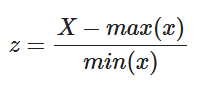

Estandarización.

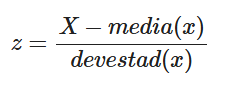

In [80]:
(5-3)/1

2.0

**Selección de caracteristicas**

* Selección Basada en la varianza
from sklearn.feature_selection import VarianceThreshold

# Eliminar características con varianza menor a un umbral
selector = VarianceThreshold(threshold=0.1)
X_selected = selector.fit_transform(X)

* Selección Basada en la Correlacion
  import numpy as np
  import seaborn as sns
  import matplotlib.pyplot as plt

# Calcular la matriz de correlación
corr_matrix = np.corrcoef(X.T)

# Visualizar la matriz de correlación
sns.heatmap(corr_matrix, annot=True)
plt.show()

* Selección Basada en la importacia del modelo
  * Arboles de Decisión
from sklearn.ensemble import RandomForestClassifier

# Entrenar el modelo de Random Forest
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Extraer la importancia de cada característica
importances = model.feature_importances_

# Visualizar las características más importantes
feature_names = df.columns
sorted_indices = np.argsort(importances)[::-1]
plt.bar(range(X.shape[1]), importances[sorted_indices])
plt.xticks(range(X.shape[1]), feature_names[sorted_indices], rotation=90)
plt.show()
  * Random Forest
  * Gradient Boosting
  * XGBoost

from xgboost import XGBClassifier
from xgboost import plot_importance

# Entrenar el modelo XGBoost
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

# Mostrar la importancia de las características
plot_importance(xgb)
plt.show()

* RFE(Metodos recursivos de eliminación)
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Crear un modelo base
model = LogisticRegression()

# Inicializar RFE con el modelo
selector = RFE(estimator=model, n_features_to_select=5, step=1)
selector = selector.fit(X_train, y_train)

# Obtener las características seleccionadas
X_selected = selector.transform(X_train)

* Y faltan...

In [81]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,F_TIENECOMPUTADOR,...,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES,PAGOMATRICULAPROPIO_No,PAGOMATRICULAPROPIO_Si
0,550236,1.0,1.0,3.0,1.0,1.0,Si,No,N,Si,...,False,False,False,False,False,False,False,False,False,True
1,98545,4.0,3.0,2.0,1.0,1.0,Si,No,N,Si,...,False,False,False,False,False,False,False,False,True,False
2,499179,3.0,0.0,3.0,1.0,0.0,Si,No,N,Si,...,False,False,False,False,False,False,False,False,True,False
3,782980,3.0,3.0,1.0,0.0,0.0,Si,No,N,No,...,False,False,False,False,True,False,False,False,True,False
4,785185,4.0,2.0,2.0,1.0,1.0,Si,No,N,Si,...,False,False,False,False,False,False,False,False,True,False


In [82]:
z.replace(["False", "Fals", "F"], 0, inplace=True)
z.replace(["True"], 1, inplace=True)

z.replace([False], 0, inplace=True)
z.replace([True], 1, inplace=True)

/tmp/ipython-input-3414078292.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  z.replace([True], 1, inplace=True)


In [83]:
z.head()

,ID,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,F_TIENECOMPUTADOR,...,DEP_QUINDIO,DEP_RISARALDA,DEP_SANTANDER,DEP_SAN_ANDRES,DEP_SUCRE,DEP_TOLIMA,DEP_VALLE,DEP_VAUPES,PAGOMATRICULAPROPIO_No,PAGOMATRICULAPROPIO_Si
0,550236,1.0,1.0,3.0,1.0,1.0,Si,No,N,Si,...,0,0,0,0,0,0,0,0,0,1
1,98545,4.0,3.0,2.0,1.0,1.0,Si,No,N,Si,...,0,0,0,0,0,0,0,0,1,0
2,499179,3.0,0.0,3.0,1.0,0.0,Si,No,N,Si,...,0,0,0,0,0,0,0,0,1,0
3,782980,3.0,3.0,1.0,0.0,0.0,Si,No,N,No,...,0,0,0,0,1,0,0,0,1,0
4,785185,4.0,2.0,2.0,1.0,1.0,Si,No,N,Si,...,0,0,0,0,0,0,0,0,1,0


In [84]:
z.isna().sum()

,0
ID,0
E_VALORMATRICULAUNIVERSIDAD,0
E_HORASSEMANATRABAJA,0
F_ESTRATOVIVIENDA,0
F_TIENEINTERNET,0
...,...
DEP_TOLIMA,0
DEP_VALLE,0
DEP_VAUPES,0
PAGOMATRICULAPROPIO_No,0


In [85]:
z.dtypes.value_counts()

,count
int64,84
float64,10
object,5


In [86]:
z.to_csv('test_preprocesamiento3.csv', index=False)